# Breast Cancer Classification — KNN, Decision Tree, SVM & Neural Network

**Dataset:** Breast Cancer Wisconsin (Diagnostic) — 569 samples, 30 numeric features computed from digitized images of fine-needle aspirates (FNA) of breast masses.

**Task:** Binary classification — predict whether a tumour is **Malignant (M)** or **Benign (B)**.

**Models covered:**
1. K-Nearest Neighbours (KNN)
2. Decision Tree
3. Support Vector Machine (SVM)
4. Neural Network (Multi-Layer Perceptron)

**Workflow:** Load data → EDA → Preprocessing → Train & tune each model → Evaluate → Compare all four.

## 1. Setup & Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report)

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 100
RANDOM_STATE = 42
print('Libraries loaded successfully')

Libraries loaded successfully


## 2. Load & Inspect the Data

In [2]:
import os

# The notebook expects the dataset in the same folder.
# (The uploaded file is a plain CSV even though its extension is .xls)
CANDIDATE_PATHS = ['Cancer_Data.csv', 'Cancer_Data_csv__1_.xls']
DATA_PATH = next((p for p in CANDIDATE_PATHS if os.path.exists(p)), CANDIDATE_PATHS[0])

df = pd.read_csv(DATA_PATH)
print('Loaded:', DATA_PATH, '| shape:', df.shape)
df.head()

Loaded: Cancer_Data.csv | shape: (569, 32)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
print('Dataset shape  :', df.shape)
print('Duplicate rows :', df.duplicated().sum())
print('Missing values :', df.isnull().sum().sum())
print()
print('Target distribution:')
print(df['diagnosis'].value_counts())
df.describe().T.head(10)

Dataset shape  : (569, 32)
Duplicate rows : 0
Missing values : 0

Target distribution:
diagnosis
B    357
M    212
Name: count, dtype: int64


,count,mean,std,min,25%,50%,75%,max
id,569.0,3.037183e+07,1.250206e+08,8670.00000,869218.00000,906024.00000,8.813129e+06,9.113205e+08
radius_mean,569.0,1.412729e+01,3.524049e+00,6.98100,11.70000,13.37000,1.578000e+01,2.811000e+01
texture_mean,569.0,1.928965e+01,4.301036e+00,9.71000,16.17000,18.84000,2.180000e+01,3.928000e+01
perimeter_mean,569.0,9.196903e+01,2.429898e+01,43.79000,75.17000,86.24000,1.041000e+02,1.885000e+02
area_mean,569.0,6.548891e+02,3.519141e+02,143.50000,420.30000,551.10000,7.827000e+02,2.501000e+03
smoothness_mean,569.0,9.636028e-02,1.406413e-02,0.05263,0.08637,0.09587,1.053000e-01,1.634000e-01
compactness_mean,569.0,1.043410e-01,5.281276e-02,0.01938,0.06492,0.09263,1.304000e-01,3.454000e-01
concavity_mean,569.0,8.879932e-02,7.971981e-02,0.00000,0.02956,0.06154,1.307000e-01,4.268000e-01
concave points_mean,569.0,4.891915e-02,3.880284e-02,0.00000,0.02031,0.03350,7.400000e-02,2.012000e-01
symmetry_mean,569.0,1.811619e-01,2.741428e-02,0.10600,0.16190,0.17920,1.957000e-01,3.040000e-01


## 3. Exploratory Data Analysis

The 30 features come in three groups of 10 (`_mean`, `_se`, `_worst`) describing cell-nucleus properties such as radius, texture, perimeter, area, concavity, etc.

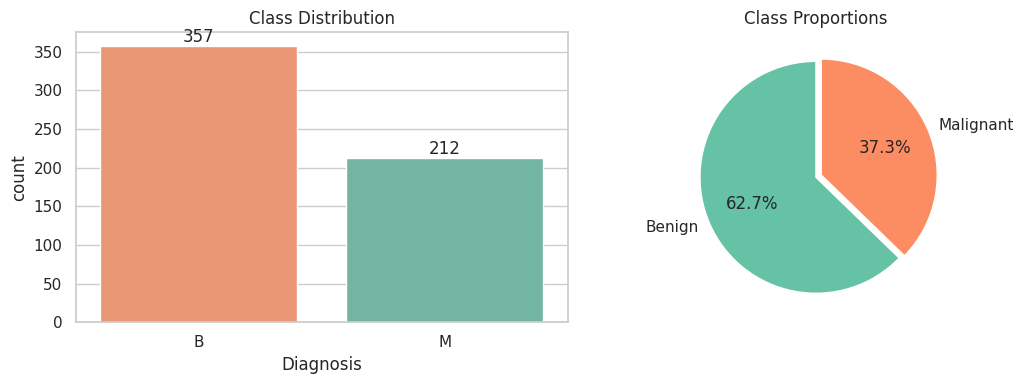

The dataset is moderately imbalanced (~63% benign, ~37% malignant),
so we use a stratified train/test split and report precision/recall/F1, not just accuracy.


In [4]:
# Class distribution
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
counts = df['diagnosis'].value_counts()

sns.countplot(data=df, x='diagnosis', hue='diagnosis', order=['B', 'M'], ax=axes[0], legend=False)
axes[0].set_title('Class Distribution')
axes[0].set_xlabel('Diagnosis')
for c in axes[0].containers:
    axes[0].bar_label(c)

axes[1].pie(counts, labels=['Benign', 'Malignant'], autopct='%1.1f%%', startangle=90,
            colors=['#66c2a5', '#fc8d62'], explode=(0, 0.05))
axes[1].set_title('Class Proportions')
plt.tight_layout()
plt.show()

print('The dataset is moderately imbalanced (~63% benign, ~37% malignant),')
print('so we use a stratified train/test split and report precision/recall/F1, not just accuracy.')

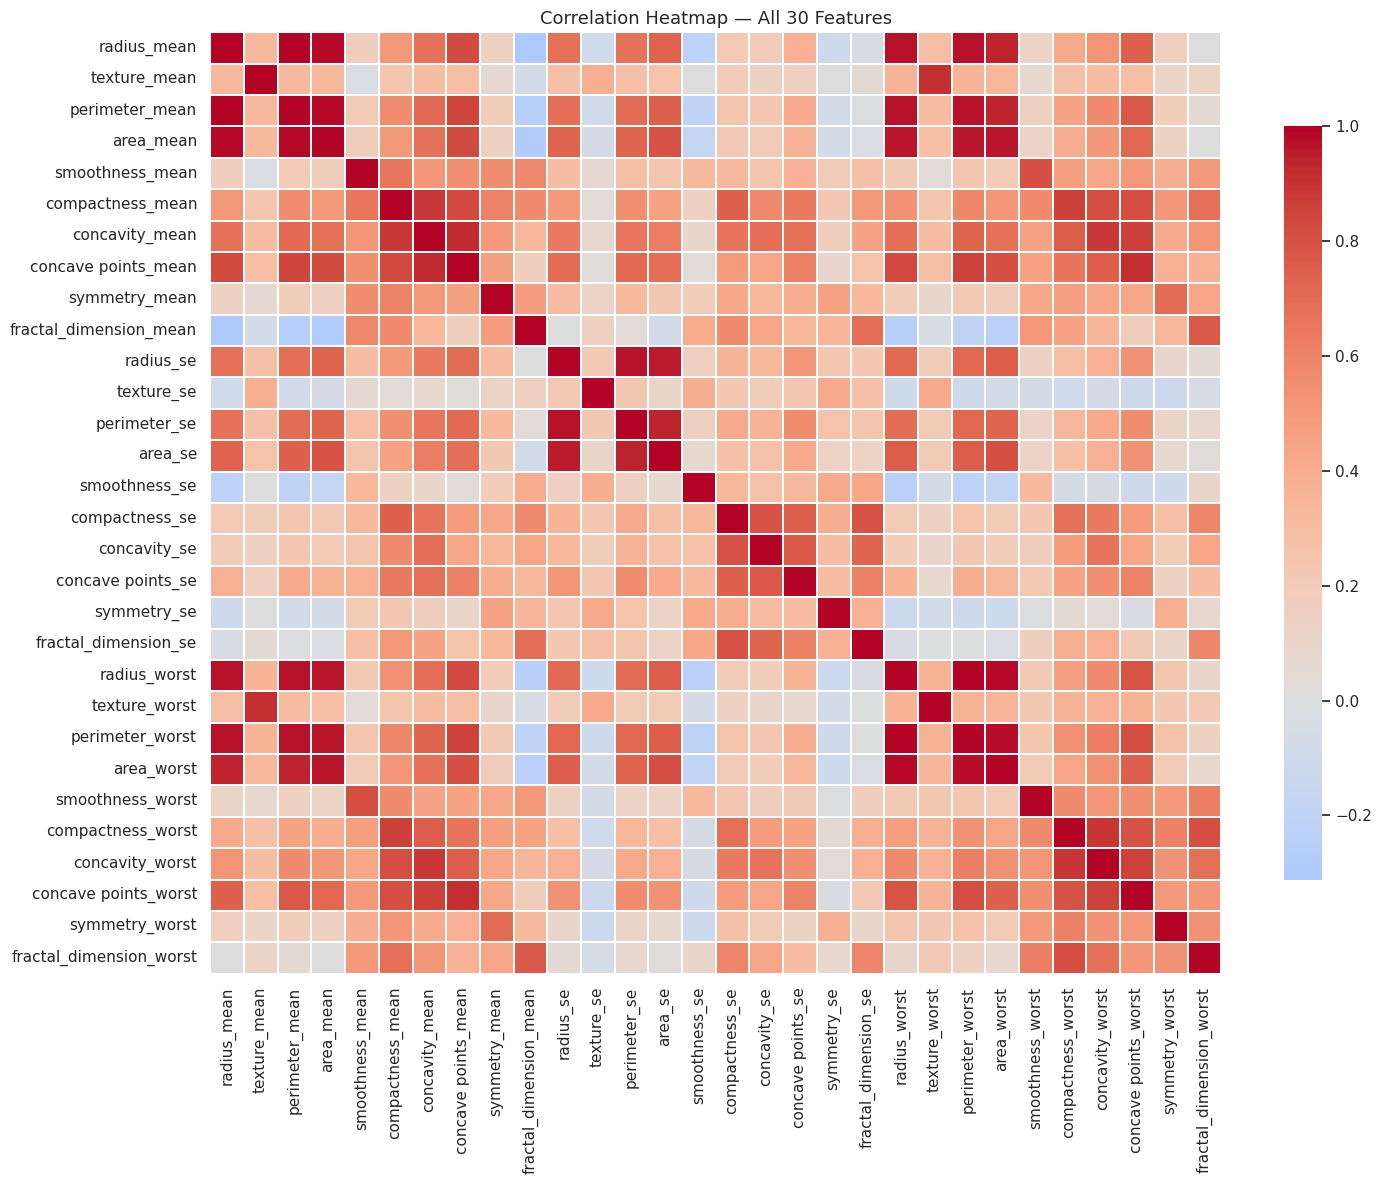

In [5]:
# Correlation structure
target_num = df['diagnosis'].map({'B': 0, 'M': 1})
features = df.drop(columns=['id', 'diagnosis'])

plt.figure(figsize=(15, 12))
sns.heatmap(features.corr(), cmap='coolwarm', center=0, linewidths=0.3, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap — All 30 Features', fontsize=13)
plt.tight_layout()
plt.show()

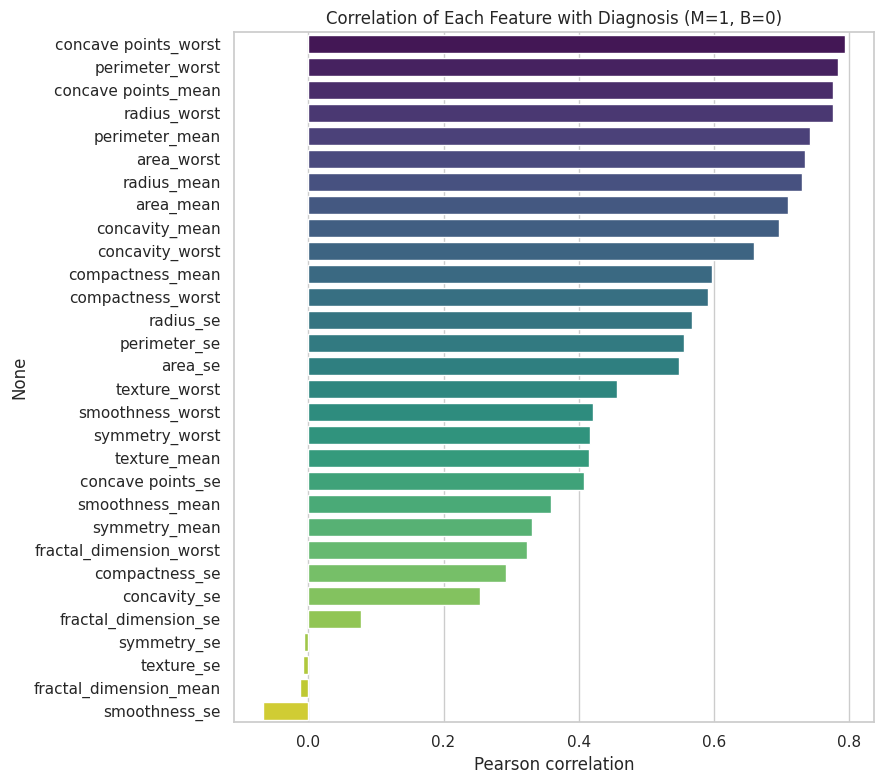

In [6]:
# Which features correlate most with the diagnosis?
corr_with_target = features.corrwith(target_num).sort_values(ascending=False)

plt.figure(figsize=(9, 8))
sns.barplot(x=corr_with_target.values, y=corr_with_target.index,
            hue=corr_with_target.index, legend=False, palette='viridis')
plt.title('Correlation of Each Feature with Diagnosis (M=1, B=0)')
plt.xlabel('Pearson correlation')
plt.tight_layout()
plt.show()

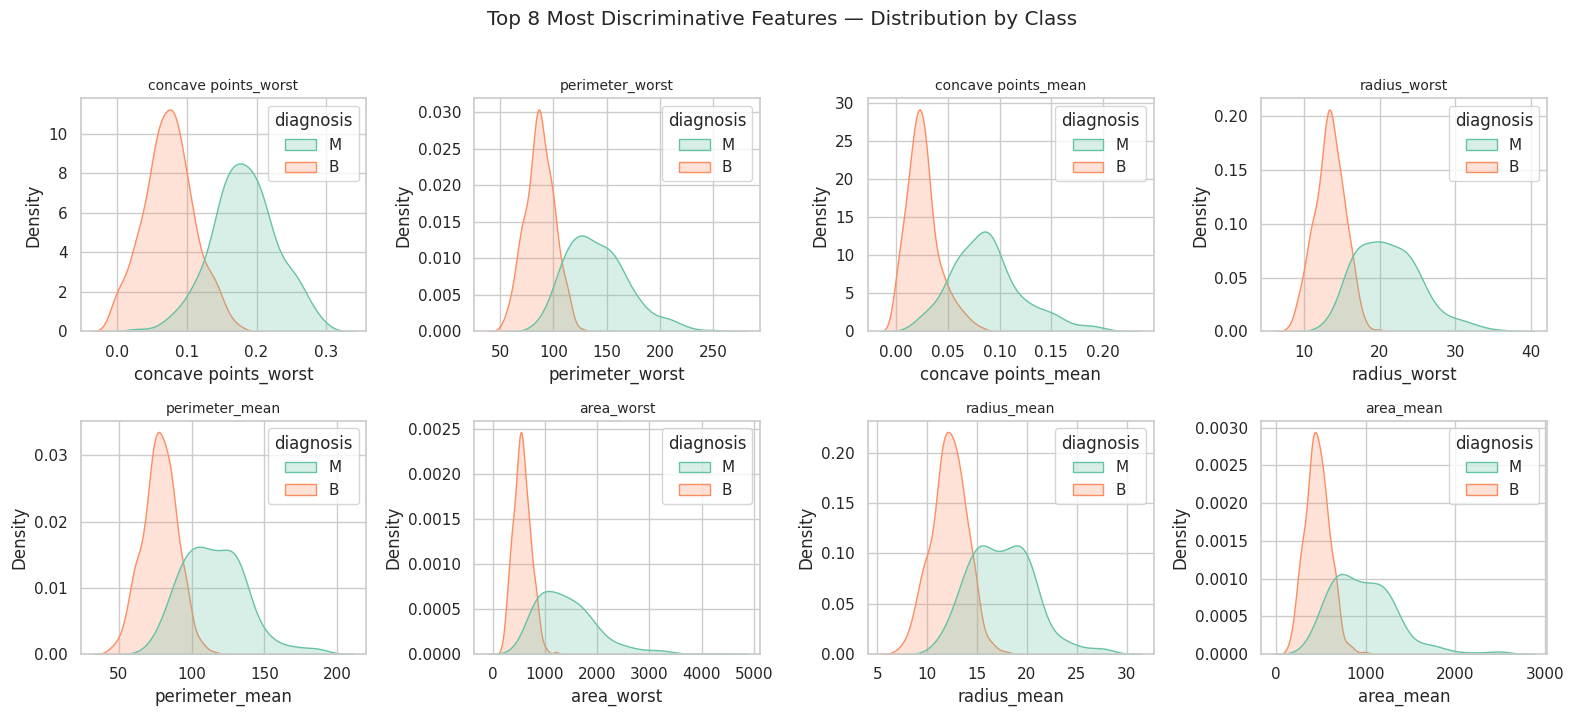

In [7]:
# Distributions of the 8 most discriminative features
top8 = corr_with_target.abs().sort_values(ascending=False).head(8).index

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.ravel(), top8):
    sns.kdeplot(data=df, x=col, hue='diagnosis', fill=True, common_norm=False,
                ax=ax, warn_singular=False)
    ax.set_title(col, fontsize=10)
plt.suptitle('Top 8 Most Discriminative Features — Distribution by Class', y=1.02)
plt.tight_layout()
plt.show()

## 4. Preprocessing

Steps:
- Drop `id` (identifier, no predictive value).
- Encode target: **B → 0, M → 1** (Malignant is the positive class).
- **Stratified** 80/20 train/test split (preserves class ratio).
- **Standardize** features (zero mean, unit variance). This is essential for KNN, SVM and the neural network, which are all sensitive to feature scale. Decision Trees are scale-invariant, so the tree is trained on the raw features.

In [8]:
X = df.drop(columns=['id', 'diagnosis'])
y = df['diagnosis'].map({'B': 0, 'M': 1})   # Malignant = positive class

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit ONLY on train (no data leakage)
X_test_scaled  = scaler.transform(X_test)

print(f'Training set : {X_train_scaled.shape[0]} samples x {X_train_scaled.shape[1]} features')
print(f'Test set     : {X_test_scaled.shape[0]} samples')
print(f'Malignant fraction — train: {y_train.mean():.2%} | test: {y_test.mean():.2%}')

Training set : 455 samples x 30 features
Test set     : 114 samples
Malignant fraction — train: 37.36% | test: 36.84%


## 5. Evaluation Helper

Every model is evaluated on the **same held-out test set** with: Accuracy, Precision, Recall, F1-score, ROC-AUC, a full classification report and a confusion matrix. Results are stored in a dictionary for the final comparison.

> In a medical context, **Recall on the malignant class matters most** — a false negative means a missed cancer case.

In [9]:
results = {}

def evaluate_model(name, model, X_te, y_te):
    y_pred = model.predict(X_te)
    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X_te)[:, 1]
    else:
        y_score = model.decision_function(X_te)

    metrics = {
        'Accuracy' : accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred),
        'Recall'   : recall_score(y_te, y_pred),
        'F1-score' : f1_score(y_te, y_pred),
        'ROC-AUC'  : roc_auc_score(y_te, y_score),
    }
    results[name] = {**metrics, '_y_pred': y_pred, '_y_score': y_score}

    print(f'================ {name} ================')
    for k, v in metrics.items():
        print(f'  {k:<10}: {v:.4f}')
    print()
    print(classification_report(y_te, y_pred, target_names=['Benign', 'Malignant']))

    fig, ax = plt.subplots(figsize=(4.5, 4))
    ConfusionMatrixDisplay(confusion_matrix(y_te, y_pred),
                           display_labels=['Benign', 'Malignant']).plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{name} — Confusion Matrix')
    plt.tight_layout()
    plt.show()

print('evaluate_model() ready')

evaluate_model() ready


## 6. Model 1 — K-Nearest Neighbours (KNN)

KNN classifies a sample by majority vote among its *k* closest training points (Euclidean distance by default). It has no real training phase — the cost is paid at prediction time — and it is highly sensitive to feature scaling, which is why it uses the standardized features.

We first select *k* with 5-fold cross-validation on the training set.

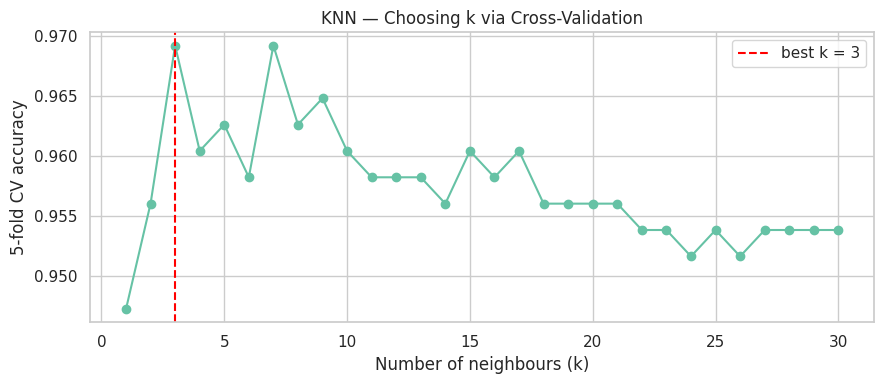

Best k = 3 | CV accuracy = 0.9692


In [10]:
k_values = range(1, 31)
cv_scores = [cross_val_score(KNeighborsClassifier(n_neighbors=k),
                             X_train_scaled, y_train, cv=5, scoring='accuracy').mean()
             for k in k_values]

best_k = k_values[int(np.argmax(cv_scores))]

plt.figure(figsize=(9, 4))
plt.plot(k_values, cv_scores, marker='o')
plt.axvline(best_k, color='red', linestyle='--', label=f'best k = {best_k}')
plt.xlabel('Number of neighbours (k)')
plt.ylabel('5-fold CV accuracy')
plt.title('KNN — Choosing k via Cross-Validation')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Best k = {best_k} | CV accuracy = {max(cv_scores):.4f}')

================ KNN ================
  Accuracy  : 0.9386
  Precision : 0.9730
  Recall    : 0.8571
  F1-score  : 0.9114
  ROC-AUC   : 0.9825

              precision    recall  f1-score   support

      Benign       0.92      0.99      0.95        72
   Malignant       0.97      0.86      0.91        42

    accuracy                           0.94       114
   macro avg       0.95      0.92      0.93       114
weighted avg       0.94      0.94      0.94       114



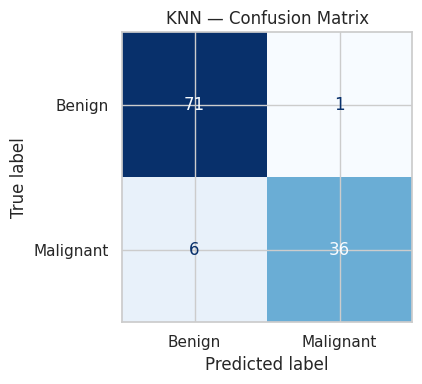

In [11]:
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_scaled, y_train)
evaluate_model('KNN', knn, X_test_scaled, y_test)

## 7. Model 2 — Decision Tree

A Decision Tree recursively splits the feature space using thresholds that maximize class purity (Gini impurity or entropy). Trees are easy to interpret and scale-invariant, but overfit easily — so we tune `max_depth`, `min_samples_split` and the split criterion with a grid search.

Best parameters : {'criterion': 'entropy', 'max_depth': 6, 'min_samples_split': 5}
Best CV accuracy: 0.9451

================ Decision Tree ================
  Accuracy  : 0.9298
  Precision : 0.9722
  Recall    : 0.8333
  F1-score  : 0.8974
  ROC-AUC   : 0.9433

              precision    recall  f1-score   support

      Benign       0.91      0.99      0.95        72
   Malignant       0.97      0.83      0.90        42

    accuracy                           0.93       114
   macro avg       0.94      0.91      0.92       114
weighted avg       0.93      0.93      0.93       114



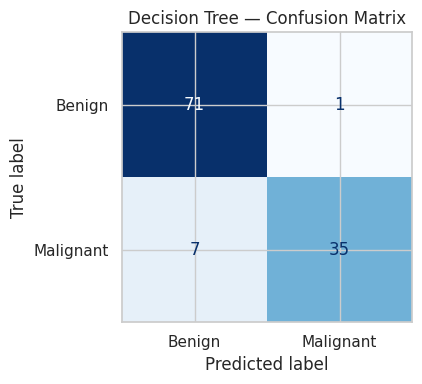

In [12]:
dt_params = {
    'max_depth': [3, 4, 5, 6, 8, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy'],
}
dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=RANDOM_STATE),
                       dt_params, cv=5, scoring='accuracy', n_jobs=-1)
dt_grid.fit(X_train, y_train)          # trees do not need feature scaling
dt = dt_grid.best_estimator_

print('Best parameters :', dt_grid.best_params_)
print(f'Best CV accuracy: {dt_grid.best_score_:.4f}')
print()
evaluate_model('Decision Tree', dt, X_test, y_test)

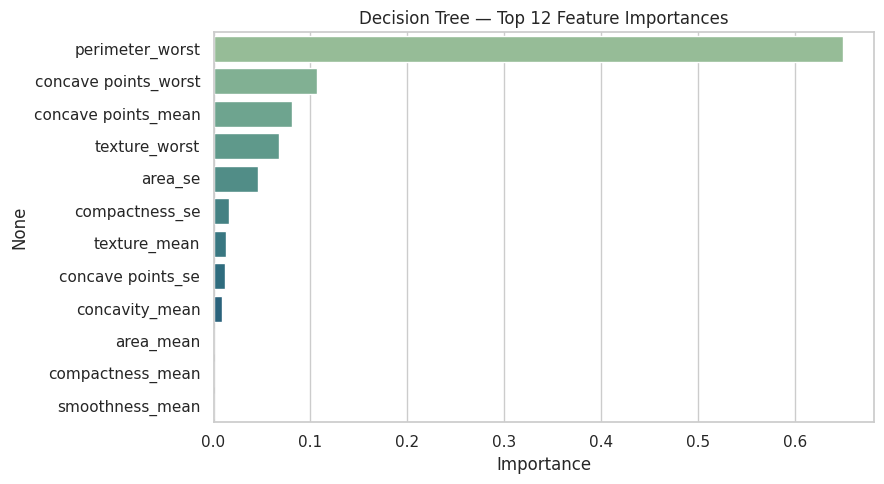

In [13]:
# Which features does the tree rely on?
importances = pd.Series(dt.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False).head(12)

plt.figure(figsize=(9, 5))
sns.barplot(x=importances.values, y=importances.index,
            hue=importances.index, legend=False, palette='crest')
plt.title('Decision Tree — Top 12 Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

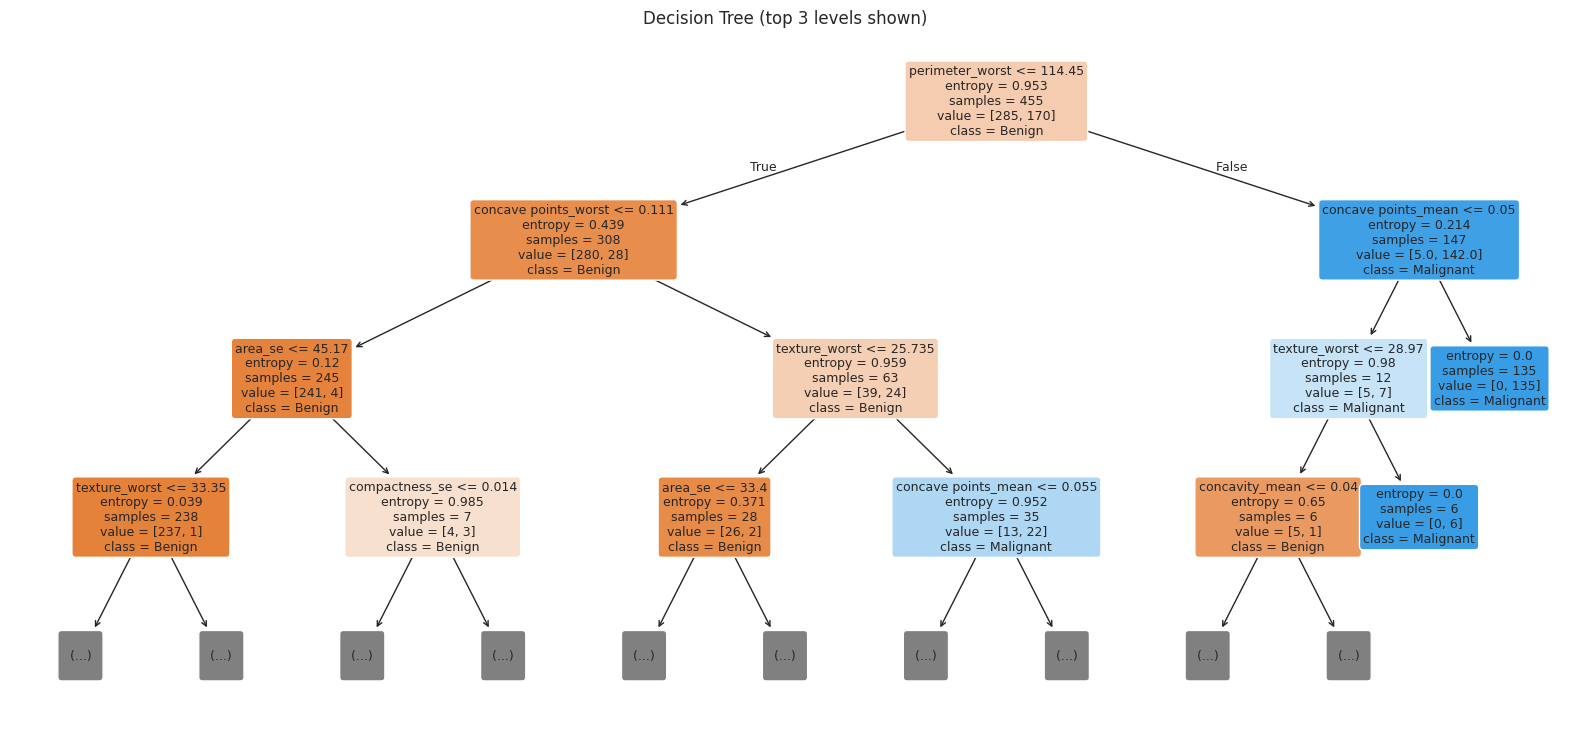

In [14]:
# Visualize the top levels of the fitted tree
plt.figure(figsize=(20, 9))
plot_tree(dt, feature_names=list(X.columns), class_names=['Benign', 'Malignant'],
          filled=True, rounded=True, max_depth=3, fontsize=9)
plt.title('Decision Tree (top 3 levels shown)')
plt.show()

## 8. Model 3 — Support Vector Machine (SVM)

An SVM finds the maximum-margin hyperplane separating the classes; the kernel trick (e.g. RBF) lets it learn non-linear boundaries. `C` controls the softness of the margin and `gamma` the reach of each training point in the RBF kernel. We grid-search kernel, `C` and `gamma`.

`probability=True` enables `predict_proba` so we can plot ROC curves later.

Best parameters : {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV accuracy: 0.9758

================ SVM ================
  Accuracy  : 0.9737
  Precision : 1.0000
  Recall    : 0.9286
  F1-score  : 0.9630
  ROC-AUC   : 0.9947

              precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        72
   Malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



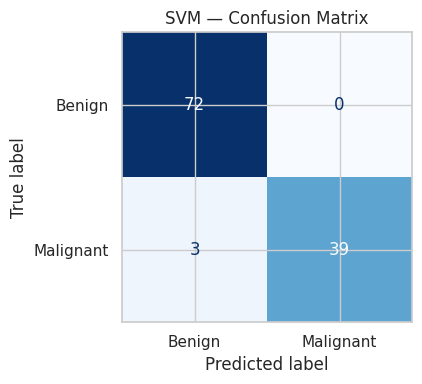

In [15]:
svm_params = {
    'kernel': ['linear', 'rbf'],
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 0.01, 0.001],
}
svm_grid = GridSearchCV(SVC(probability=True, random_state=RANDOM_STATE),
                        svm_params, cv=5, scoring='accuracy', n_jobs=-1)
svm_grid.fit(X_train_scaled, y_train)
svm = svm_grid.best_estimator_

print('Best parameters :', svm_grid.best_params_)
print(f'Best CV accuracy: {svm_grid.best_score_:.4f}')
print()
evaluate_model('SVM', svm, X_test_scaled, y_test)

## 9. Model 4 — Neural Network (Multi-Layer Perceptron)

A feed-forward neural network trained with backpropagation (Adam optimizer):

- **Architecture:** 30 inputs → Dense(64, ReLU) → Dense(32, ReLU) → sigmoid output
- **Regularization:** L2 penalty (`alpha`) + early stopping on a 15% validation split
- Trained on the standardized features (gradient-based models converge poorly on unscaled data).

Training stopped after 50 epochs (early stopping)


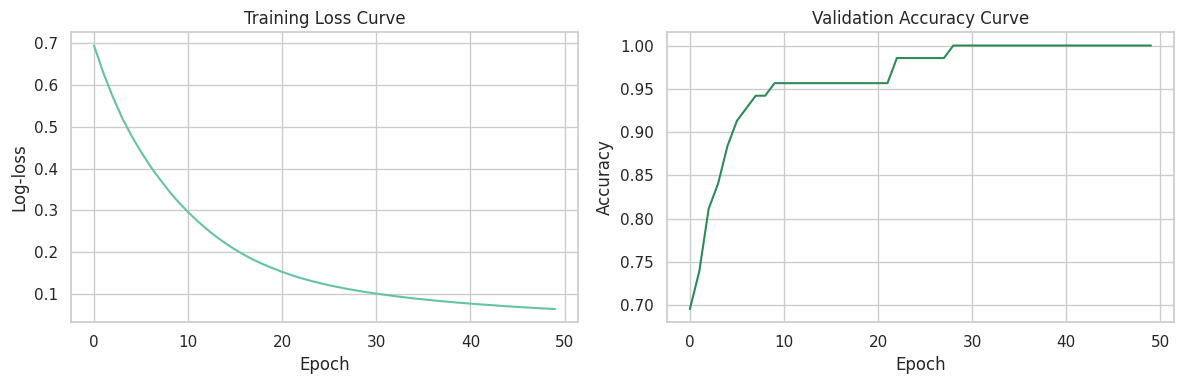

In [16]:
mlp = MLPClassifier(hidden_layer_sizes=(64, 32),
                    activation='relu',
                    solver='adam',
                    alpha=1e-4,
                    learning_rate_init=1e-3,
                    max_iter=500,
                    early_stopping=True,
                    validation_fraction=0.15,
                    n_iter_no_change=20,
                    random_state=RANDOM_STATE)
mlp.fit(X_train_scaled, y_train)
print(f'Training stopped after {mlp.n_iter_} epochs (early stopping)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(mlp.loss_curve_)
axes[0].set_title('Training Loss Curve')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Log-loss')
axes[1].plot(mlp.validation_scores_, color='seagreen')
axes[1].set_title('Validation Accuracy Curve')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
plt.tight_layout()
plt.show()

================ Neural Network (MLP) ================
  Accuracy  : 0.9561
  Precision : 0.9744
  Recall    : 0.9048
  F1-score  : 0.9383
  ROC-AUC   : 0.9970

              precision    recall  f1-score   support

      Benign       0.95      0.99      0.97        72
   Malignant       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



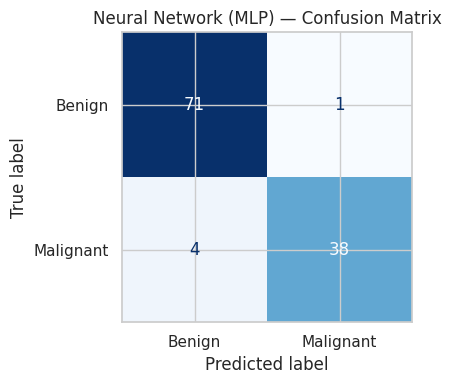

In [17]:
evaluate_model('Neural Network (MLP)', mlp, X_test_scaled, y_test)

## 10. Model Comparison

,Accuracy,Precision,Recall,F1-score,ROC-AUC
SVM,0.9737,1.0000,0.9286,0.9630,0.9947
Neural Network (MLP),0.9561,0.9744,0.9048,0.9383,0.9970
KNN,0.9386,0.9730,0.8571,0.9114,0.9825
Decision Tree,0.9298,0.9722,0.8333,0.8974,0.9433


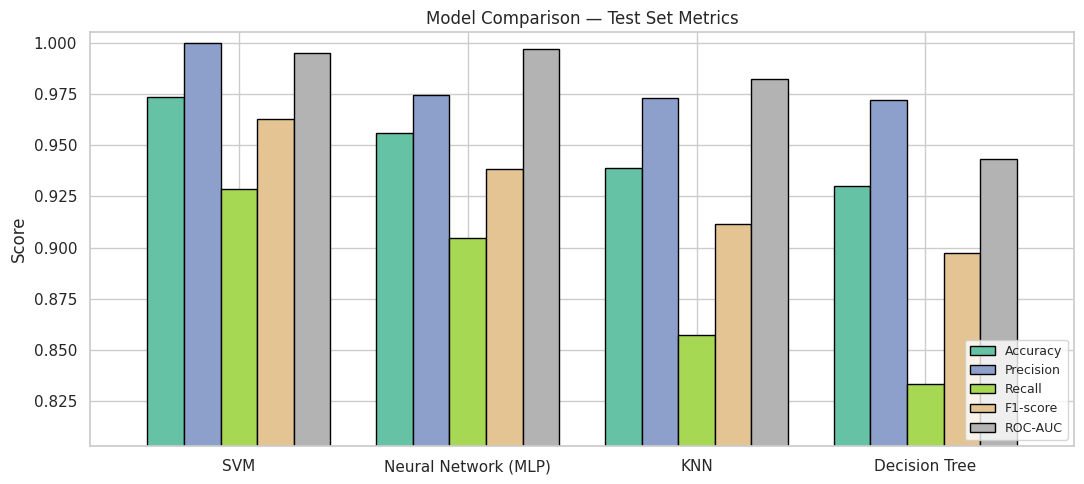

In [18]:
comparison = pd.DataFrame({name: {k: v for k, v in res.items() if not k.startswith('_')}
                           for name, res in results.items()}).T
comparison = comparison.sort_values('F1-score', ascending=False)
display(comparison.round(4))

ax = comparison.plot(kind='bar', figsize=(11, 5), rot=0, colormap='Set2',
                     edgecolor='black', width=0.8)
ax.set_ylim(max(0.0, comparison.values.min() - 0.03), 1.005)
ax.set_title('Model Comparison — Test Set Metrics')
ax.set_ylabel('Score')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

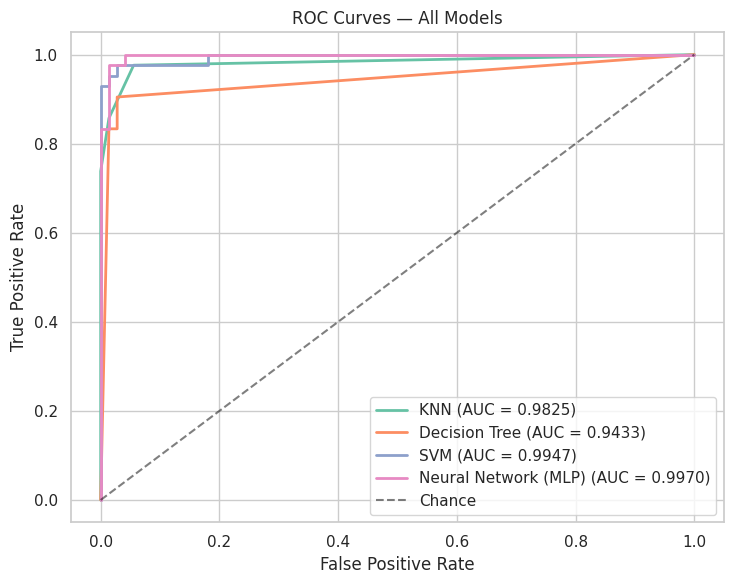

In [19]:
# ROC curves for all four models
plt.figure(figsize=(7.5, 6))
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['_y_score'])
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {res['ROC-AUC']:.4f})")
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

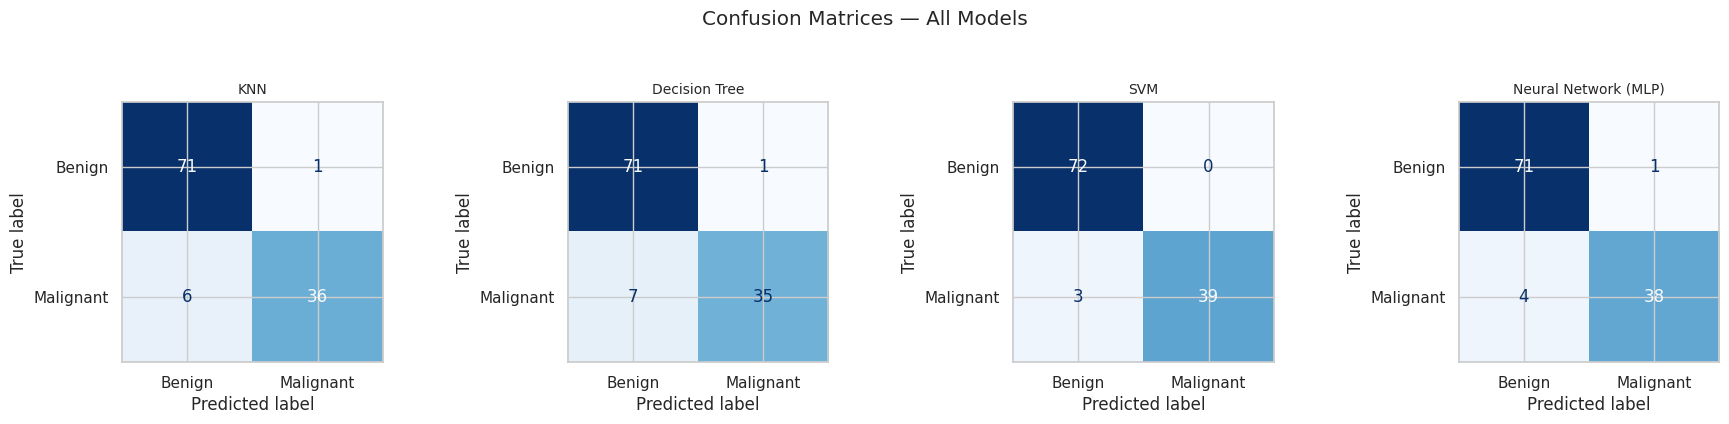

In [20]:
# Confusion matrices side by side
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['_y_pred'])
    ConfusionMatrixDisplay(cm, display_labels=['Benign', 'Malignant']).plot(
        ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(name, fontsize=10)
plt.suptitle('Confusion Matrices — All Models', y=1.05)
plt.tight_layout()
plt.show()

In [21]:
best_model = comparison['F1-score'].idxmax()

print('=' * 60)
print('FINAL RANKING (by F1-score on the held-out test set)')
print('=' * 60)
for i, (name, row) in enumerate(comparison.iterrows(), 1):
    print(f"{i}. {name:<22} F1 = {row['F1-score']:.4f} | Acc = {row['Accuracy']:.4f} | AUC = {row['ROC-AUC']:.4f}")

fn_counts = {name: int(confusion_matrix(y_test, res['_y_pred'])[1, 0])
             for name, res in results.items()}
print()
print('False negatives (missed malignant cases) per model:')
for name, fn in fn_counts.items():
    print(f'  {name:<22}: {fn}')
print()
print(f'Best overall model: {best_model}')

FINAL RANKING (by F1-score on the held-out test set)
1. SVM                    F1 = 0.9630 | Acc = 0.9737 | AUC = 0.9947
2. Neural Network (MLP)   F1 = 0.9383 | Acc = 0.9561 | AUC = 0.9970
3. KNN                    F1 = 0.9114 | Acc = 0.9386 | AUC = 0.9825
4. Decision Tree          F1 = 0.8974 | Acc = 0.9298 | AUC = 0.9433

False negatives (missed malignant cases) per model:
  KNN                   : 6
  Decision Tree         : 7
  SVM                   : 3
  Neural Network (MLP)  : 4

Best overall model: SVM


## 11. Conclusions

- All four classifiers perform strongly on this dataset (accuracy and ROC-AUC well above 0.9), confirming that the 30 FNA-derived features are highly informative.
- **SVM and the MLP** typically lead — both benefit from standardized features and can model smooth non-linear boundaries. **KNN** is close behind once *k* is tuned. The **Decision Tree** is the most interpretable but usually the weakest single model here, as axis-aligned splits overfit small datasets.
- **Feature scaling matters:** KNN, SVM and the MLP were trained on standardized data; the tree was not, because it is scale-invariant.
- **Metric choice matters:** with ~63/37 class imbalance and a medical use case, recall on the malignant class (fewest false negatives) is more important than raw accuracy — see the false-negative counts above.

**Possible extensions:** k-fold CV on the full pipeline, ensemble models (Random Forest, XGBoost), PCA before KNN/SVM, threshold tuning to maximize malignant recall, and SHAP for model explanation.